# 🏊 YMCA Greenfield — Active Members Analysis
**Goal:** Clean the raw export, understand member demographics, membership types, discounts, payment behavior, and age distribution.

---
**Data note:** The raw CSV has a 4-row header block before the actual column names (report title, URI, generated timestamp, blank row). We skip those with `skiprows=4`.

### Setup & Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.colab import files

# Consistent visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load the Data
Upload `Active_Members__YMCA_.csv` when prompted.

In [27]:
filepath = '/content/Active Members (YMCA).csv'
raw = pd.read_csv(filepath, skiprows=4)
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')]

print(f'Loaded {len(raw):,} rows × {raw.shape[1]} columns')
raw.head(11)

Loaded 5,250 rows × 17 columns


,UID,MID,Full Name,Type,DOB,Counts Towards Units,Home Branch,Discount,Recurring Bill,Email,Gender,Payment Type,PrimaryMemberFirstName,PrimaryMemberLastName,PrimaryMemberBirthdate,PrimaryMemberEmail,PrimaryMemberAge
0,209284,157637,"Cross, Sharon",ADULT COUPLE,09/22/1963 (62yrs),Yes,Greenfield,Barter,0.0,scrossma77@gmail.com,Female,Invoice,Sharon,Cross,1963-09-22,scrossma77@gmail.com,62
1,209284,212208,"Cross, Russell",ADULT COUPLE,11/23/1961 (64yrs),Yes,Greenfield,Barter,0.0,rscross208@gmail.com,Male,Invoice,Sharon,Cross,1963-09-22,scrossma77@gmail.com,62
2,209283,212204,"Lorenzana, Sincere",1 ADULT FAMILY,06/11/2017 (9yrs),Yes,Greenfield,NaN,55.0,ssn00pyz86@gmail.com,NaN,Credit Card,Rey,Lorenzana,1986-01-06,ssn00pyz86@gmail.com,40
3,209283,212205,"Lorenzana, Rey",1 ADULT FAMILY,01/06/1986 (40yrs),Yes,Greenfield,NaN,55.0,ssn00pyz86@gmail.com,NaN,Credit Card,Rey,Lorenzana,1986-01-06,ssn00pyz86@gmail.com,40
4,209280,212199,"Velazquez, Victor",ADULT,12/25/2003 (22yrs),Yes,Greenfield,Scholarship 60%,220.8,vela122v@gmail.com,Male,Invoice,Victor,Velazquez,2003-12-25,vela122v@gmail.com,22
5,209278,212195,"Schneider, Sophia",TEEN,10/01/2009 (16yrs),Yes,Greenfield,Employee Membership,0.0,sophieschneider0808@icloud.com,Female,Invoice,Sophia,Schneider,2009-10-01,sophieschneider0808@icloud.com,16
6,209277,212194,"Drew, Rebecca",ADULT,09/27/1995 (30yrs),Yes,Greenfield,Employee Membership,0.0,rebeccaracheldrew@gmail.com,Female,Invoice,Rebecca,Drew,1995-09-27,rebeccaracheldrew@gmail.com,30
7,209276,212193,"Quatacker, Raymond",ADULT,12/22/1993 (32yrs),Yes,Greenfield,Scholarship 60%,18.4,NaN,Non-binary,Invoice,Raymond,Quatacker,1993-12-22,NaN,32
8,209275,212192,"Ramos, Christopher (Toba)",ADULT,08/27/1993 (32yrs),Yes,Greenfield,Scholarship 60%,18.4,NaN,Male,Invoice,Christopher (Toba),Ramos,1993-08-27,NaN,32
9,209274,212187,"Lucy, Kate",FAMILY,05/24/1987 (39yrs),Yes,Greenfield,NaN,68.0,Kate.m.lucy@gmail.com,Female,Credit Card,Kate,Lucy,1987-05-24,Kate.m.lucy@gmail.com,39


## 2. Data Cleaning
We'll fix:
- Parse individual member age from the `DOB` field (e.g. `"09/22/1963 (62yrs)"`)
- Parse clean DOB as a proper `date`
- Standardise `Discount` — fill blanks with `"None"`
- Create a binary `HasDiscount` flag
- Cast `Recurring Bill` to float (already numeric; confirm)
- Strip whitespace from string columns

In [28]:
df = raw.copy()

# ── String columns: strip leading/trailing whitespace ──────────────────────────
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda s: s.str.strip())

# ── Individual member age: extracted from DOB string ──────────────────────────
# DOB looks like "09/22/1963 (62yrs)" — grab the numeric part in parentheses
df['IndividualAge'] = (
    df['DOB']
    .str.extract(r'\((\d+)yrs\)', expand=False)
    .astype(float)
)

# ── DOB as a clean date column ─────────────────────────────────────────────────
df['DOB_clean'] = pd.to_datetime(
    df['DOB'].str.extract(r'^(\d{2}/\d{2}/\d{4})', expand=False),
    format='%m/%d/%Y',
    errors='coerce'
)

# ── Discount: fill NaN → 'None' so we can group on it ─────────────────────────
df['Discount'] = df['Discount'].fillna('None')
df['HasDiscount'] = df['Discount'] != 'None'   # True/False flag

# ── Recurring Bill: already float; rename for clarity ─────────────────────────
df['MonthlyBill'] = df['Recurring Bill'].astype(float)

# ── Gender: fill blank → 'Not Specified' ──────────────────────────────────────
df['Gender'] = df['Gender'].replace('', np.nan).fillna('Not Specified')

# ── Age bands (individual member) ─────────────────────────────────────────────
age_bins   = [0, 12, 17, 25, 34, 49, 64, 79, 89, 120]
age_labels = ['0–12', '13–17', '18–25', '26–34', '35–49', '50–64', '65–79', '80–89', '90+']
df['AgeBand'] = pd.cut(df['IndividualAge'], bins=age_bins, labels=age_labels, right=True)

print('Cleaning complete. Shape:', df.shape)
df[['Full Name','Type','IndividualAge','AgeBand','Discount','HasDiscount','MonthlyBill','Gender']].head(5)

Cleaning complete. Shape: (5250, 22)


,Full Name,Type,IndividualAge,AgeBand,Discount,HasDiscount,MonthlyBill,Gender
0,"Cross, Sharon",ADULT COUPLE,62.0,50–64,Barter,True,0.0,Female
1,"Cross, Russell",ADULT COUPLE,64.0,50–64,Barter,True,0.0,Male
2,"Lorenzana, Sincere",1 ADULT FAMILY,9.0,0–12,None,False,55.0,Not Specified
3,"Lorenzana, Rey",1 ADULT FAMILY,40.0,35–49,None,False,55.0,Not Specified
4,"Velazquez, Victor",ADULT,22.0,18–25,Scholarship 60%,True,220.8,Male


## 3. Quick Data Quality Check

In [29]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0].to_string())

print('\n=== Key Counts ===')
print(f'  Total member records : {len(df):,}')
print(f'  Unique households (UID): {df["UID"].nunique():,}')
print(f'  Avg members per household: {len(df)/df["UID"].nunique():.2f}')
print(f'  Records with no email : {df["Email"].isna().sum():,}')
print(f'  Records with no gender: {(df["Gender"]=="Not Specified").sum():,}')

=== Missing Values ===
Email                 521
PrimaryMemberEmail    280
AgeBand                11

=== Key Counts ===
  Total member records : 5,250
  Unique households (UID): 3,390
  Avg members per household: 1.55
  Records with no email : 521
  Records with no gender: 666


## 4. Membership Type Distribution

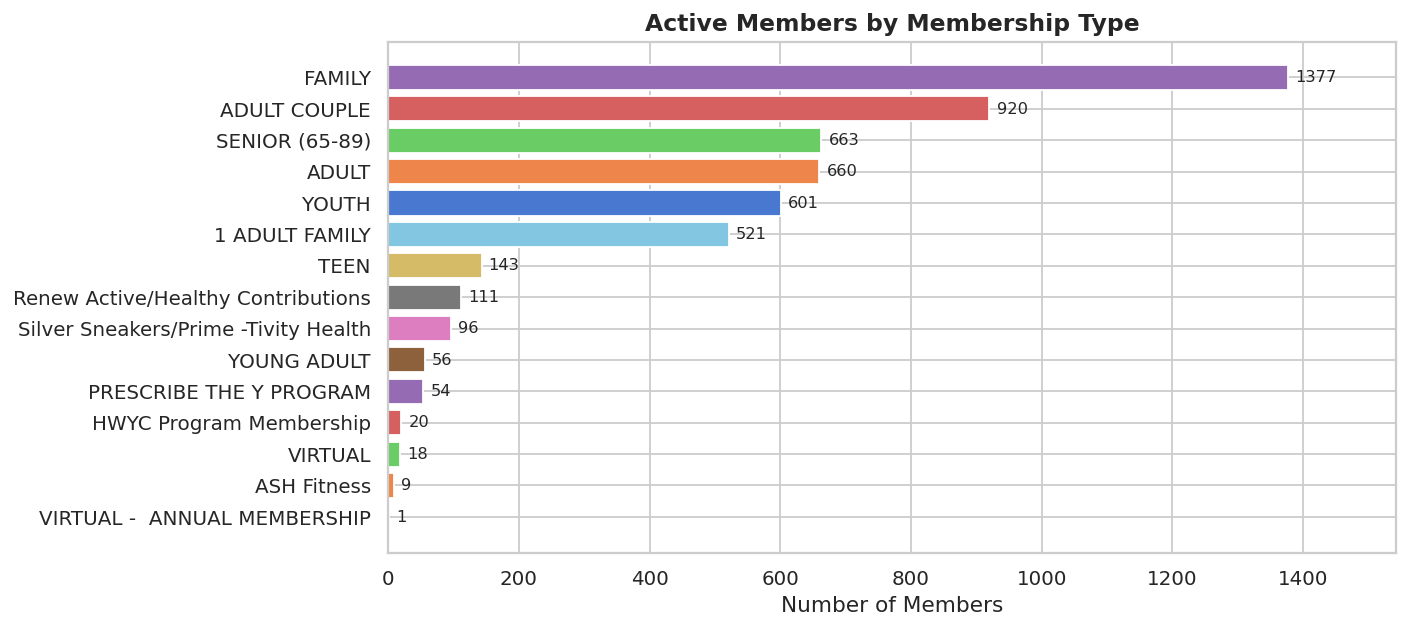

Type
FAMILY                                  1377
ADULT COUPLE                             920
SENIOR (65-89)                           663
ADULT                                    660
YOUTH                                    601
1 ADULT FAMILY                           521
TEEN                                     143
Renew Active/Healthy Contributions       111
Silver Sneakers/Prime -Tivity Health      96
YOUNG ADULT                               56
PRESCRIBE THE Y PROGRAM                   54
HWYC Program Membership                   20
VIRTUAL                                   18
ASH Fitness                                9
VIRTUAL -  ANNUAL MEMBERSHIP               1


In [30]:
type_counts = df['Type'].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(type_counts.index[::-1], type_counts.values[::-1], color=sns.color_palette('muted', len(type_counts)))
ax.bar_label(bars, fmt='%d', padding=4, fontsize=9)
ax.set_xlabel('Number of Members')
ax.set_title('Active Members by Membership Type', fontsize=13, fontweight='bold')
ax.set_xlim(0, type_counts.max() * 1.12)
plt.tight_layout()
plt.show()

print(type_counts.to_string())

## 5. Age Distribution (Individual Members)

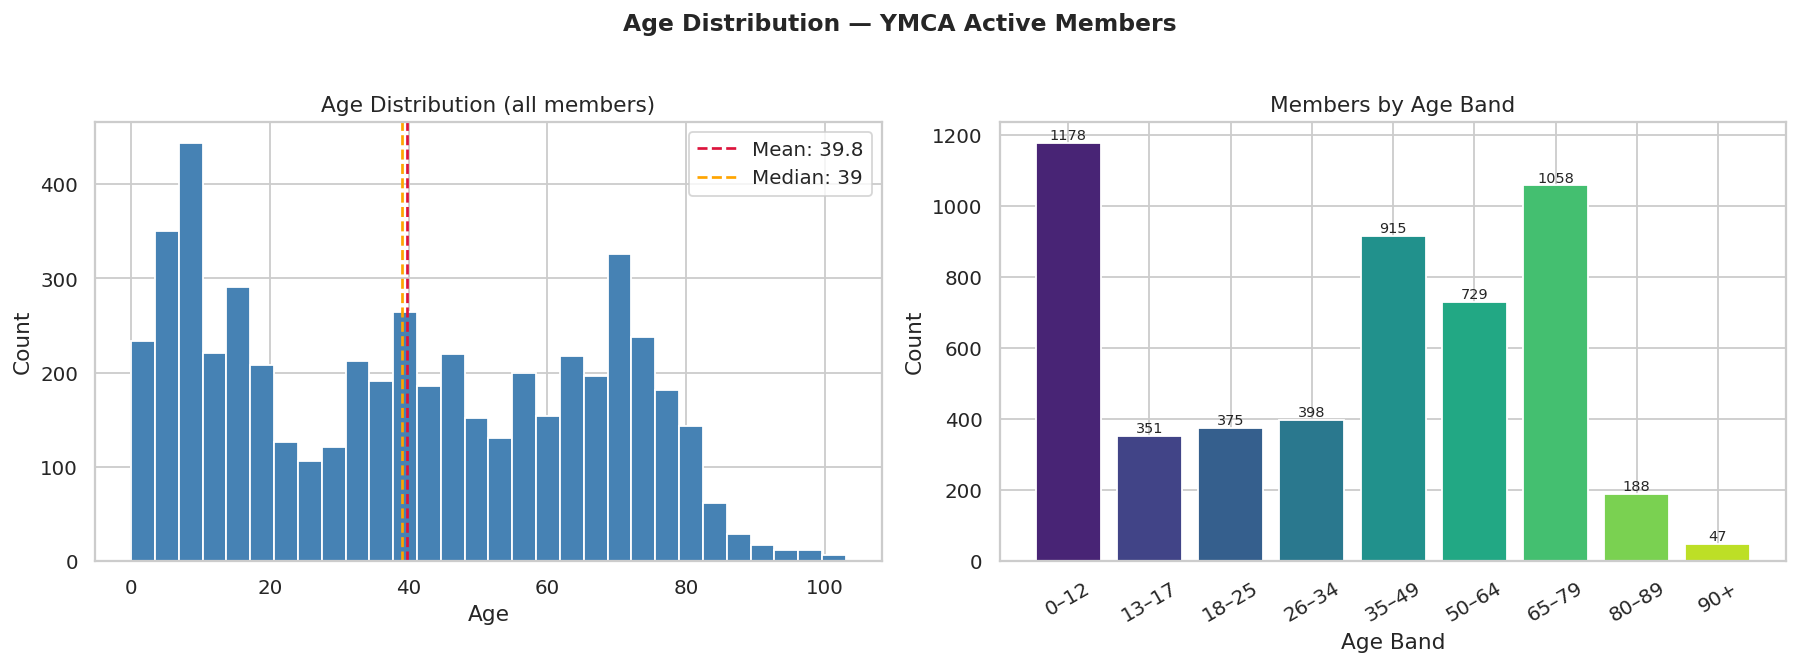

Summary stats:
count    5250.0
mean       39.8
std        26.0
min         0.0
25%        14.0
50%        39.0
75%        64.0
max       103.0
Name: IndividualAge, dtype: float64


In [31]:
ages = df['IndividualAge'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(ages, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(ages.mean(), color='crimson', linestyle='--', label=f'Mean: {ages.mean():.1f}')
axes[0].axvline(ages.median(), color='orange', linestyle='--', label=f'Median: {ages.median():.0f}')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution (all members)')
axes[0].legend()

# Age band bar chart
band_counts = df['AgeBand'].value_counts().sort_index()
axes[1].bar(band_counts.index.astype(str), band_counts.values, color=sns.color_palette('viridis', len(band_counts)))
axes[1].set_xlabel('Age Band')
axes[1].set_ylabel('Count')
axes[1].set_title('Members by Age Band')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(band_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=8)

plt.suptitle('Age Distribution — YMCA Active Members', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Summary stats:')
print(ages.describe().round(1))

## 6. Gender Breakdown

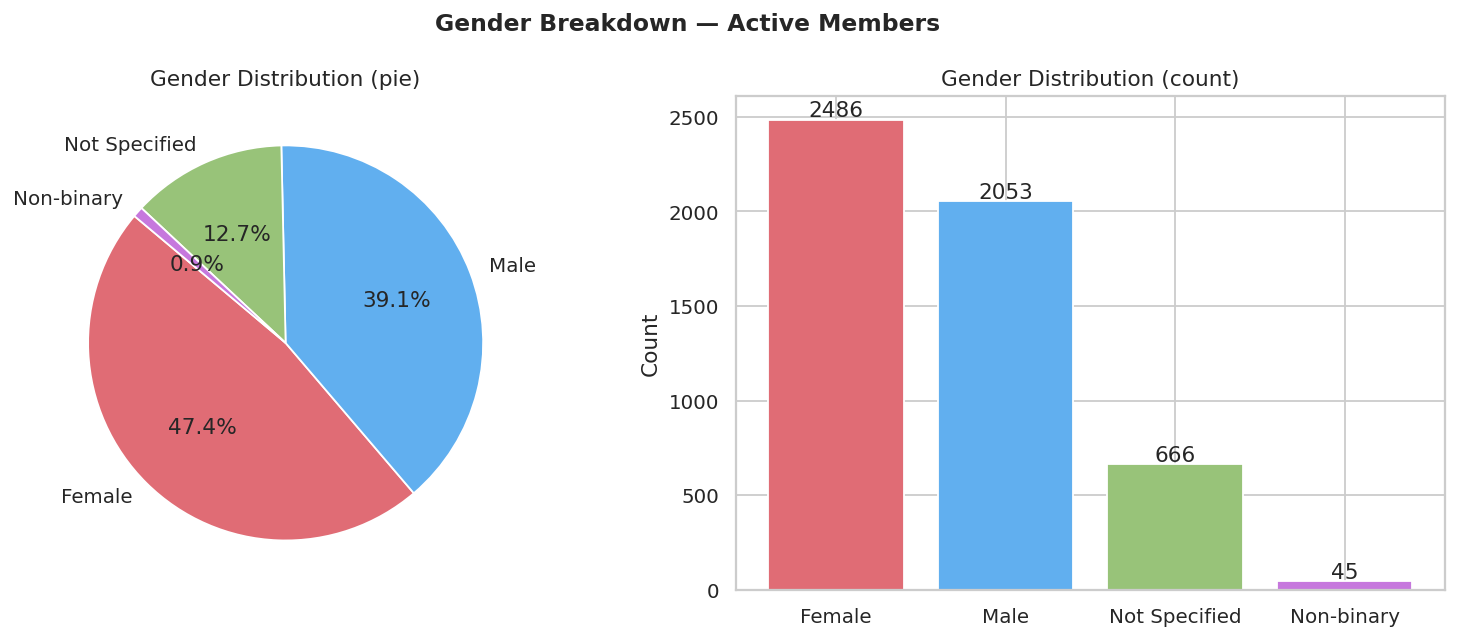

Gender
Female           2486
Male             2053
Not Specified     666
Non-binary         45
Name: count, dtype: int64


In [32]:
gender_counts = df['Gender'].value_counts()
colors = ['#e06c75', '#61afef', '#98c379', '#c678dd']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colors[:len(gender_counts)], startangle=140)
axes[0].set_title('Gender Distribution (pie)')

# Bar
axes[1].bar(gender_counts.index, gender_counts.values, color=colors[:len(gender_counts)])
axes[1].set_ylabel('Count')
axes[1].set_title('Gender Distribution (count)')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 15, str(v), ha='center')

plt.suptitle('Gender Breakdown — Active Members', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(gender_counts)

## 7. Discount Analysis
About 23% of members receive some form of discount. Let's see which types are most common and which membership types benefit most.

Members with a discount: 1,218 / 5,250  (23.2%)


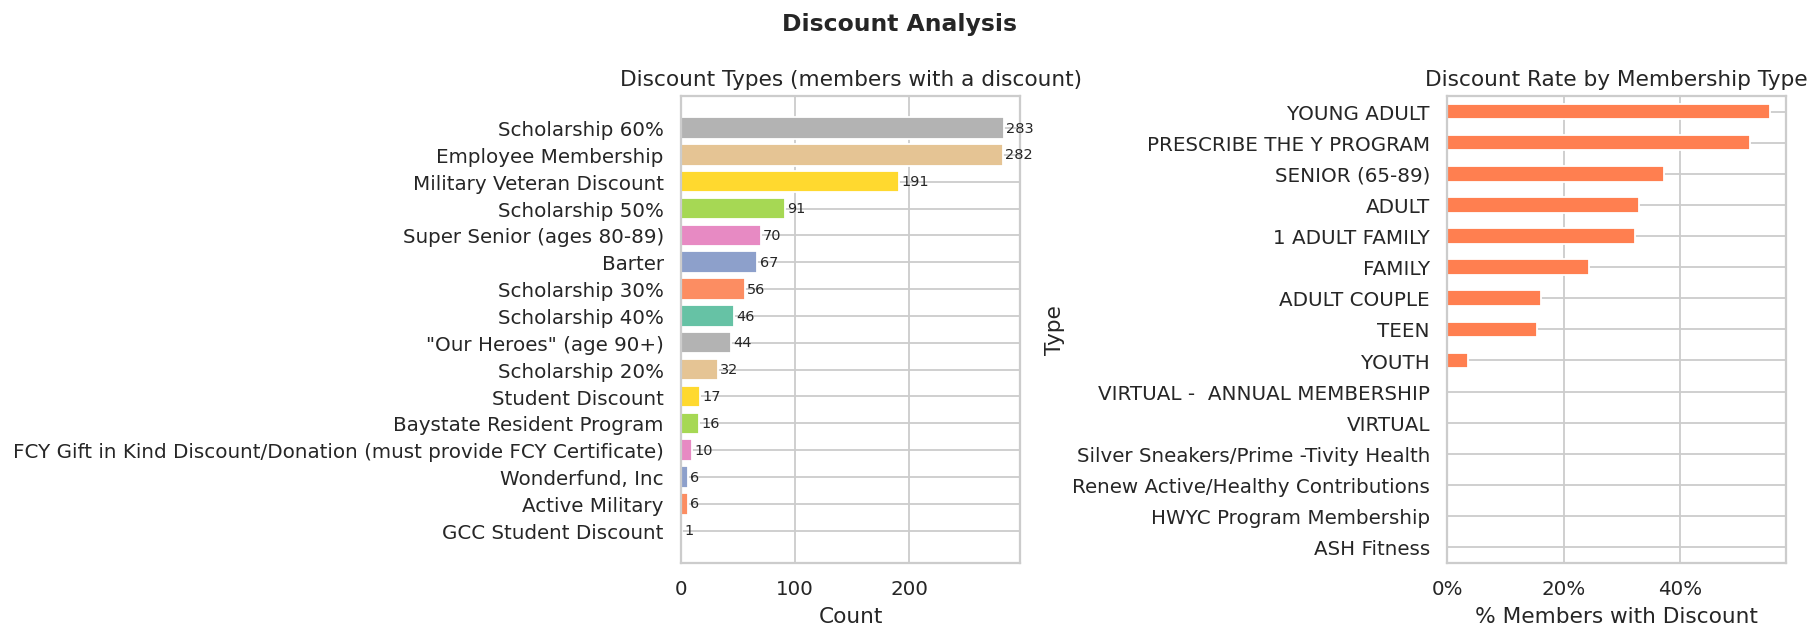

In [33]:
# ── Overall discount rate ──────────────────────────────────────────────────────
disc_rate = df['HasDiscount'].mean() * 100
print(f'Members with a discount: {df["HasDiscount"].sum():,} / {len(df):,}  ({disc_rate:.1f}%)')

# ── Discount type breakdown (exclude 'None') ───────────────────────────────────
disc_counts = df[df['Discount'] != 'None']['Discount'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: discount types
axes[0].barh(disc_counts.index[::-1], disc_counts.values[::-1],
             color=sns.color_palette('Set2', len(disc_counts)))
axes[0].set_xlabel('Count')
axes[0].set_title('Discount Types (members with a discount)')
for i, v in enumerate(disc_counts.values[::-1]):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=8)

# Right: % with discount by membership type
disc_by_type = (
    df.groupby('Type')['HasDiscount']
    .mean()
    .sort_values(ascending=True)
    * 100
)
disc_by_type.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_xlabel('% Members with Discount')
axes[1].set_title('Discount Rate by Membership Type')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Discount Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Payment Method Distribution

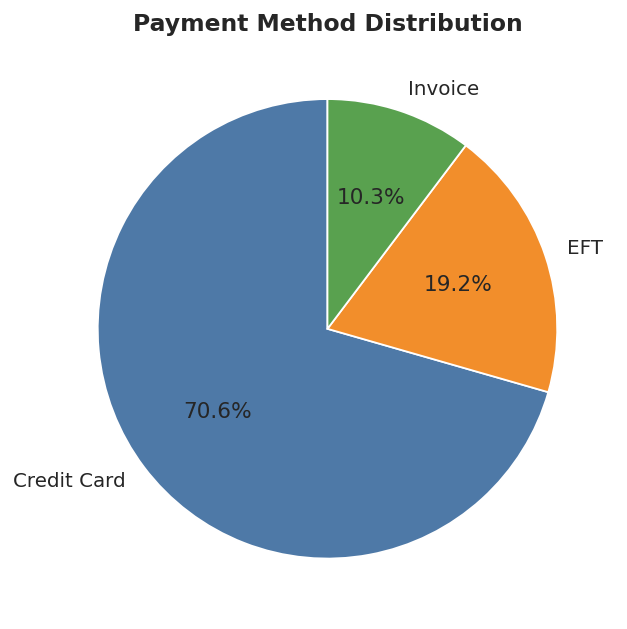

Payment Type
Credit Card    3704
EFT            1006
Invoice         540
Name: count, dtype: int64


In [34]:
pay_counts = df['Payment Type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    pay_counts, labels=pay_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=['#4e79a7', '#f28e2b', '#59a14f']
)
ax.set_title('Payment Method Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(pay_counts)

## 9. Monthly Billing Analysis
Note: Many subsidised / insurance-covered memberships (e.g. Silver Sneakers, Renew Active) bill $0.

Total monthly recurring revenue (all households): $174,059.13
  Households paying $0 (fully subsidised): 433
  Households paying >$0: 2957


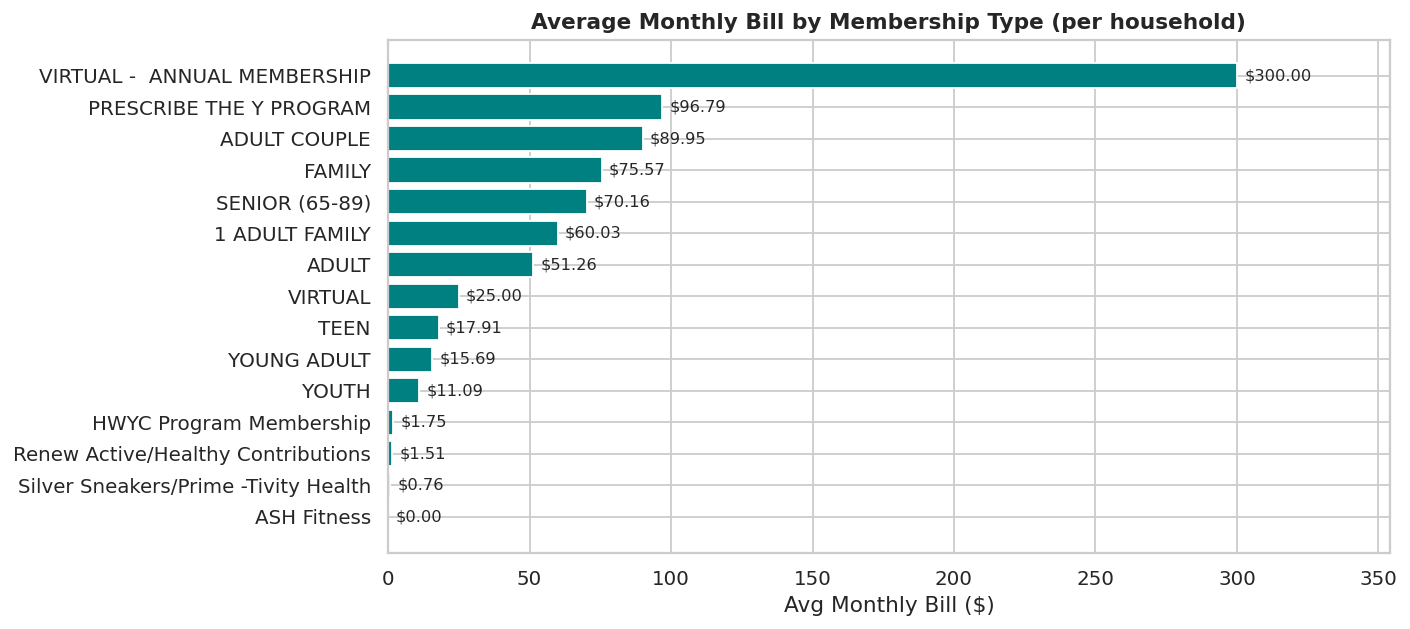

In [35]:
# Per-household billing (de-duplicate by UID so family members aren't counted multiple times)
hh_bill = df.drop_duplicates('UID')[['UID', 'Type', 'MonthlyBill', 'HasDiscount']]

print(f'Total monthly recurring revenue (all households): ${hh_bill["MonthlyBill"].sum():,.2f}')
print(f'  Households paying $0 (fully subsidised): {(hh_bill["MonthlyBill"]==0).sum()}')
print(f'  Households paying >$0: {(hh_bill["MonthlyBill"]>0).sum()}')

# Average bill by membership type
avg_bill = hh_bill.groupby('Type')['MonthlyBill'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(avg_bill.index[::-1], avg_bill.values[::-1], color='teal')
ax.bar_label(bars, fmt='$%.2f', padding=4, fontsize=9)
ax.set_xlabel('Avg Monthly Bill ($)')
ax.set_title('Average Monthly Bill by Membership Type (per household)', fontsize=12, fontweight='bold')
ax.set_xlim(0, avg_bill.max() * 1.18)
plt.tight_layout()
plt.show()

## 10. Age by Membership Type (Box Plot)

/tmp/ipykernel_13056/4207506001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Type', y='IndividualAge', order=order,
/tmp/ipykernel_13056/4207506001.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)


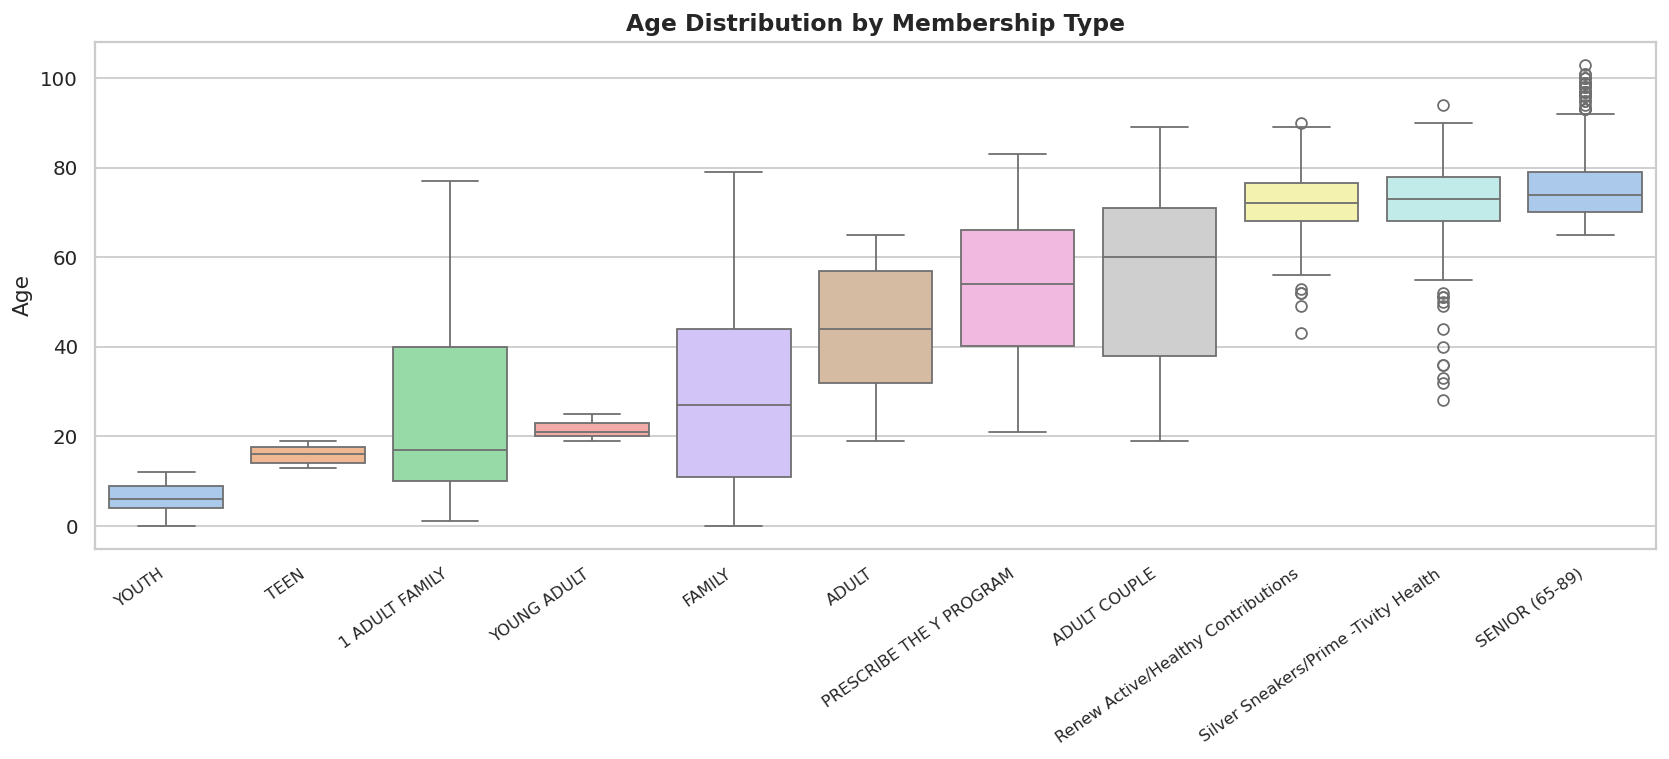

In [36]:
# Limit to types with enough members for a meaningful box plot (>= 30)
common_types = df['Type'].value_counts()[df['Type'].value_counts() >= 30].index
subset = df[df['Type'].isin(common_types)]

# Sort types by median age
order = subset.groupby('Type')['IndividualAge'].median().sort_values().index

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=subset, x='Type', y='IndividualAge', order=order,
            palette='pastel', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('Age')
ax.set_title('Age Distribution by Membership Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Discount Rate by Age Band

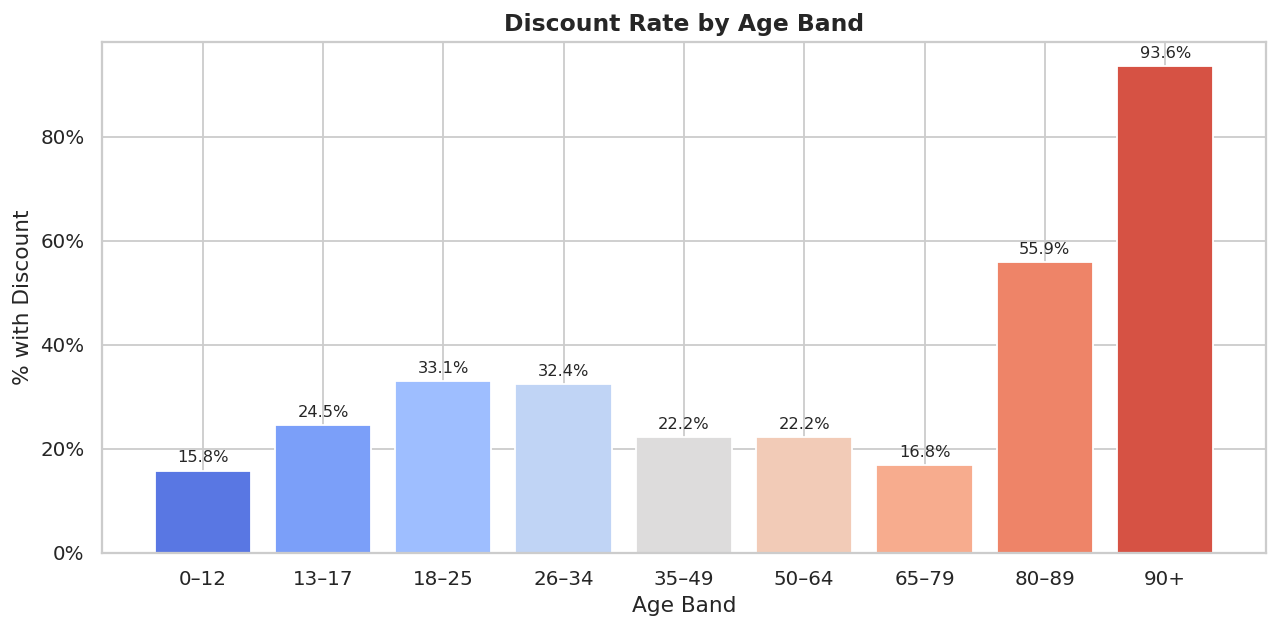

            N  DiscountPct
AgeBand                   
0–12     1178         15.8
13–17     351         24.5
18–25     375         33.1
26–34     398         32.4
35–49     915         22.2
50–64     729         22.2
65–79    1058         16.8
80–89     188         55.9
90+        47         93.6


In [37]:
disc_age = (
    df.groupby('AgeBand', observed=True)['HasDiscount']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'DiscountRate', 'count': 'N'})
)
disc_age['DiscountPct'] = disc_age['DiscountRate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(disc_age.index.astype(str), disc_age['DiscountPct'],
              color=sns.color_palette('coolwarm', len(disc_age)))
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('Age Band')
ax.set_ylabel('% with Discount')
ax.set_title('Discount Rate by Age Band', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

print(disc_age[['N', 'DiscountPct']].round(1))

## 12. Household Size Distribution
How many members per account (UID)?

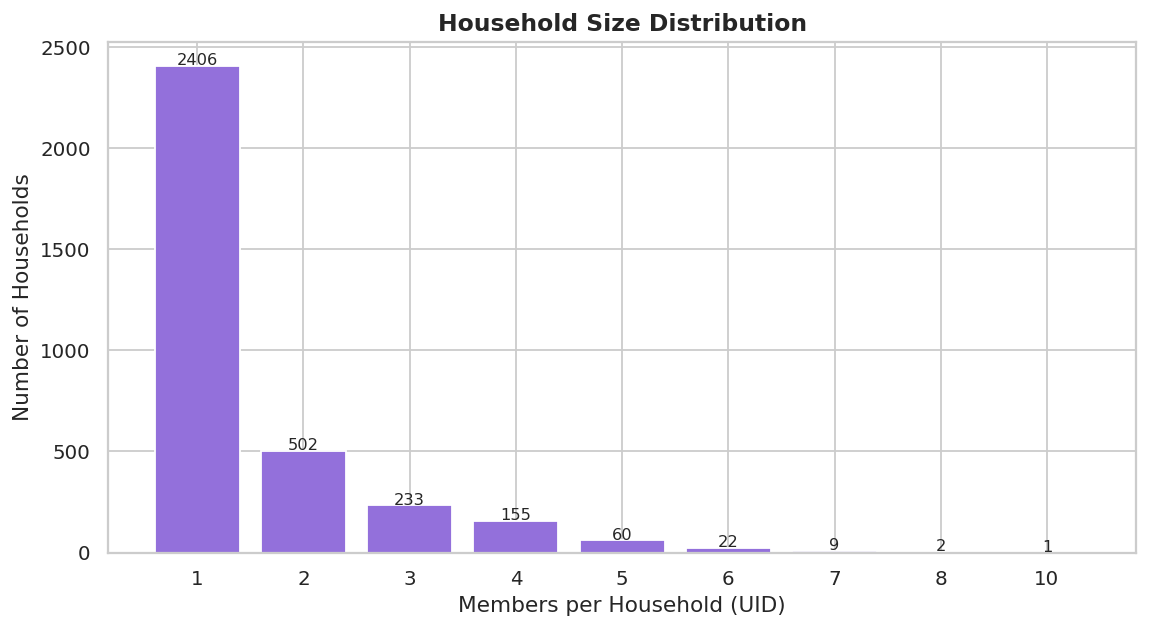

1     2406
2      502
3      233
4      155
5       60
6       22
7        9
8        2
10       1
Name: count, dtype: int64


In [38]:
hh_size = df.groupby('UID').size().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(hh_size.index.astype(str), hh_size.values, color='mediumpurple')
ax.set_xlabel('Members per Household (UID)')
ax.set_ylabel('Number of Households')
ax.set_title('Household Size Distribution', fontsize=13, fontweight='bold')
for i, v in enumerate(hh_size.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(hh_size)

## 13. Summary Table — Key Stats by Membership Type

In [39]:
summary = (
    df.groupby('Type')
    .agg(
        Members       = ('MID', 'count'),
        Avg_Age       = ('IndividualAge', 'mean'),
        Pct_Discount  = ('HasDiscount', 'mean'),
        Avg_Bill      = ('MonthlyBill', 'mean'),
        Female_Pct    = ('Gender', lambda x: (x == 'Female').mean()),
        Male_Pct      = ('Gender', lambda x: (x == 'Male').mean()),
    )
    .sort_values('Members', ascending=False)
)

summary['Avg_Age']      = summary['Avg_Age'].round(1)
summary['Pct_Discount'] = (summary['Pct_Discount'] * 100).round(1).astype(str) + '%'
summary['Avg_Bill']     = summary['Avg_Bill'].round(2).apply(lambda x: f'${x:,.2f}')
summary['Female_Pct']   = (summary['Female_Pct'] * 100).round(1).astype(str) + '%'
summary['Male_Pct']     = (summary['Male_Pct'] * 100).round(1).astype(str) + '%'

summary

,Members,Avg_Age,Pct_Discount,Avg_Bill,Female_Pct,Male_Pct
Type,,,,,,
FAMILY,1377,27.9,24.4%,$73.90,41.9%,42.8%
ADULT COUPLE,920,55.7,16.1%,$89.70,46.5%,38.8%
SENIOR (65-89),663,75.2,37.1%,$70.16,59.1%,35.9%
ADULT,660,44.4,32.9%,$51.31,48.3%,37.1%
YOUTH,601,6.3,3.7%,$11.09,47.3%,37.8%
1 ADULT FAMILY,521,24.2,32.2%,$56.87,50.9%,31.9%
TEEN,143,15.9,15.4%,$17.91,25.2%,63.6%
Renew Active/Healthy Contributions,111,72.0,0.0%,$1.46,44.1%,40.5%
Silver Sneakers/Prime -Tivity Health,96,70.1,0.0%,$0.76,55.2%,37.5%


## 14. Export Cleaned Data
Download a clean CSV with all the new engineered columns. This will be a new excel file!

In [40]:
export_cols = [
    'UID', 'MID', 'Full Name', 'Type', 'IndividualAge', 'AgeBand',
    'DOB_clean', 'Gender', 'Discount', 'HasDiscount',
    'MonthlyBill', 'Payment Type', 'Home Branch', 'Email'
]

clean_df = df[export_cols].copy()
clean_df.to_csv('YMCA_Active_Members_CLEAN.csv', index=False)
files.download('YMCA_Active_Members_CLEAN.csv')
print('Clean file downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Clean file downloaded!
